In [1]:
import sccellfie
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import glasbey

import textwrap

## To avoid warnings
import warnings
warnings.filterwarnings("ignore")

/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import anndata as ad

In [3]:
sc.settings.figdir = '/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/da-figures/'

In [4]:
adata = sccellfie.io.load_adata(folder='/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie',
                                filename='Honda_tumor_scCellFie_without_cycling_ctrl'
                               )

/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie_without_cycling_ctrl.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie_without_cycling_ctrl_reactions.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie_without_cycling_ctrl_metabolic_tasks.h5ad was correctly loaded


In [5]:
adata

AnnData object with n_obs × n_vars = 21580 × 683
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_counts'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells', 'gene_count_corr'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'l

In [6]:
adata.metabolic_tasks

AnnData object with n_obs × n_vars = 21580 × 184
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_counts'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

## Defining cell types

In [7]:
cell_group = 'cell_annotation_05'

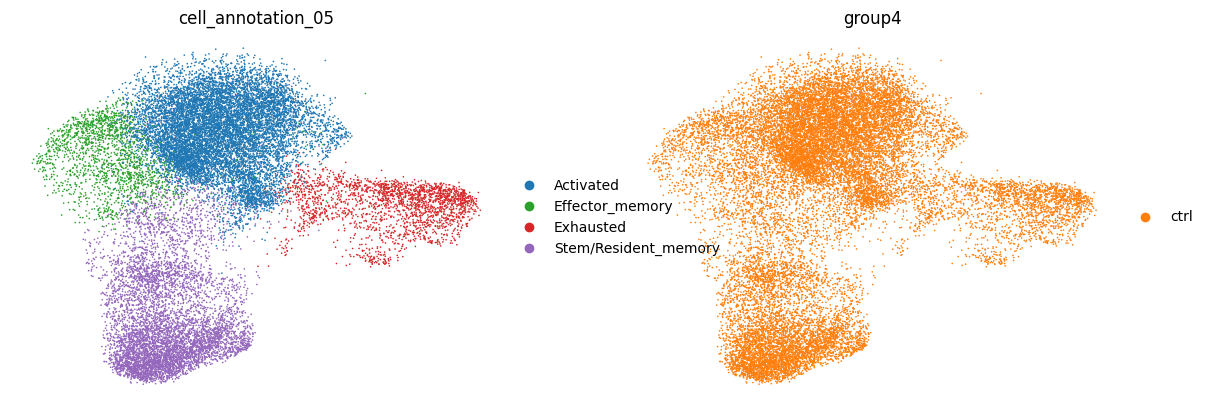

In [8]:
sc.pl.umap(adata, color=[cell_group,"group4"],frameon=False)

In [9]:
adata.metabolic_tasks.obs

,sample_id,batch,initial_size_unspliced,initial_size_spliced,initial_size,adata_name,condition,batch_id,n_genes_by_counts,log1p_n_genes_by_counts,...,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,rna_leiden,rna_leiden_05,gex03,group4,cell_annotation_05,n_counts
10mix-ICI1_AAAGATGGTGATGCCC-1,2021_10mix-ICI1,2021_10mix-ICI1,307.0,158.0,158.0,adata_10mix_ICI1,10mix,ICI1,2359,7.766417,...,0.0,0.0,0.0,0.0,1,2,2,ctrl,Effector_memory,164.000015
10mix-ICI1_AAACCTGAGGGCACTA-1,2021_10mix-ICI1,2021_10mix-ICI1,242.0,213.0,213.0,adata_10mix_ICI1,10mix,ICI1,2209,7.700748,...,0.0,0.0,0.0,0.0,1,2,2,ctrl,Effector_memory,164.000031
10mix-ICI1_AAAGATGCAGTAGAGC-1,2021_10mix-ICI1,2021_10mix-ICI1,273.0,173.0,173.0,adata_10mix_ICI1,10mix,ICI1,2267,7.726654,...,0.0,0.0,0.0,0.0,0,0,0,ctrl,Activated,164.000015
10mix-ICI1_AAACCTGCAGTTCCCT-1,2021_10mix-ICI1,2021_10mix-ICI1,291.0,219.0,219.0,adata_10mix_ICI1,10mix,ICI1,1768,7.478170,...,0.0,0.0,0.0,0.0,3,1,1,ctrl,Stem/Resident_memory,163.251129
10mix-ICI1_AAAGCAACAGTCTTCC-1,2021_10mix-ICI1,2021_10mix-ICI1,169.0,144.0,144.0,adata_10mix_ICI1,10mix,ICI1,1537,7.338238,...,0.0,0.0,0.0,0.0,7,1,1,ctrl,Stem/Resident_memory,162.861115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10mix-ICI2_TTTGTCAAGTGGACGT-1,2021_10mix-ICI2,2021_10mix-ICI2,204.0,230.0,230.0,adata_10mix_ICI2,10mix,ICI2,1566,7.356918,...,0.0,0.0,0.0,0.0,0,0,0,ctrl,Activated,164.000000
10mix-ICI2_TTTGGTTGTAGTGAAT-1,2021_10mix-ICI2,2021_10mix-ICI2,267.0,207.0,207.0,adata_10mix_ICI2,10mix,ICI2,1386,7.234898,...,0.0,0.0,0.0,0.0,3,1,2,ctrl,Stem/Resident_memory,163.999985
10mix-ICI2_TTTGTCACAAGAGTCG-1,2021_10mix-ICI2,2021_10mix-ICI2,152.0,94.0,94.0,adata_10mix_ICI2,10mix,ICI2,1469,7.293018,...,0.0,0.0,0.0,0.0,2,3,1,ctrl,Stem/Resident_memory,162.255295
10mix-ICI2_TTTGTCATCAGCTCGG-1,2021_10mix-ICI2,2021_10mix-ICI2,189.0,66.0,66.0,adata_10mix_ICI2,10mix,ICI2,1317,7.183871,...,0.0,0.0,0.0,0.0,2,3,1,ctrl,Stem/Resident_memory,163.999985


## Identification of metabolic markers

## Detection using TF-IDF

In [10]:
mrks = sccellfie.external.quick_markers(adata.metabolic_tasks,
                                        cluster_key=cell_group,
                                        n_markers=20,
                                        express_cut=5*np.log(2))

<Axes: >

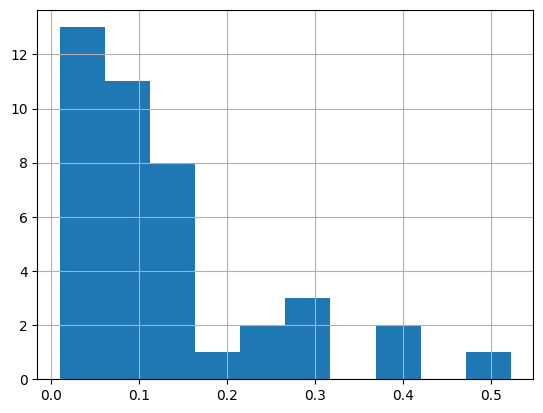

In [11]:
# Visualize TF-IDF score distribution
mrks['tf_idf'].hist()

Text(0, 0.5, 'IDF')

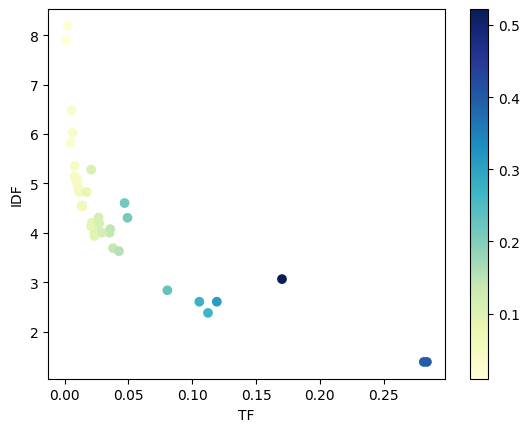

In [12]:
# Scatter plot of TF vs IDF with TF-IDF as color
scatter = plt.scatter(mrks['tf'], mrks['idf'], c=mrks['tf_idf'], cmap='YlGnBu')
plt.colorbar(scatter)
plt.xlabel('TF')
plt.ylabel('IDF')

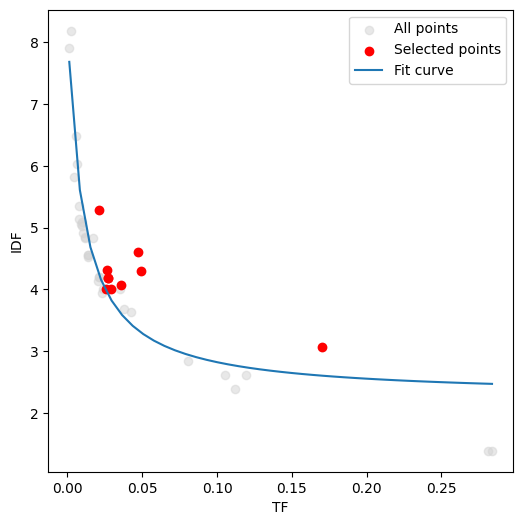

In [13]:
x_col = 'tf'
y_col = 'idf'
df = mrks
tfidf_threshold = 0.1
tf_ratio = 1.2

# Visualization
plt.figure(figsize=(6, 6))
# Plot all points
plt.scatter(df[x_col], df[y_col], alpha=0.5, c='lightgray', label='All points')
# Plot selected points
filtered_mrks, curve = sccellfie.external.filter_tfidf_markers(df, tf_col=x_col, idf_col=y_col,
                                                              tfidf_threshold=tfidf_threshold,
                                                              tf_ratio=tf_ratio)
plt.scatter(filtered_mrks[x_col], filtered_mrks[y_col], c='red', label='Selected points')
plt.plot(*curve, label='Fit curve')
plt.xlabel('TF')
plt.ylabel('IDF')
plt.legend()

In [14]:
# Get unique list of filtered markers
tf_idf_mrks = filtered_mrks['gene'].unique().tolist()
len(tf_idf_mrks)

10

## Logistic regression

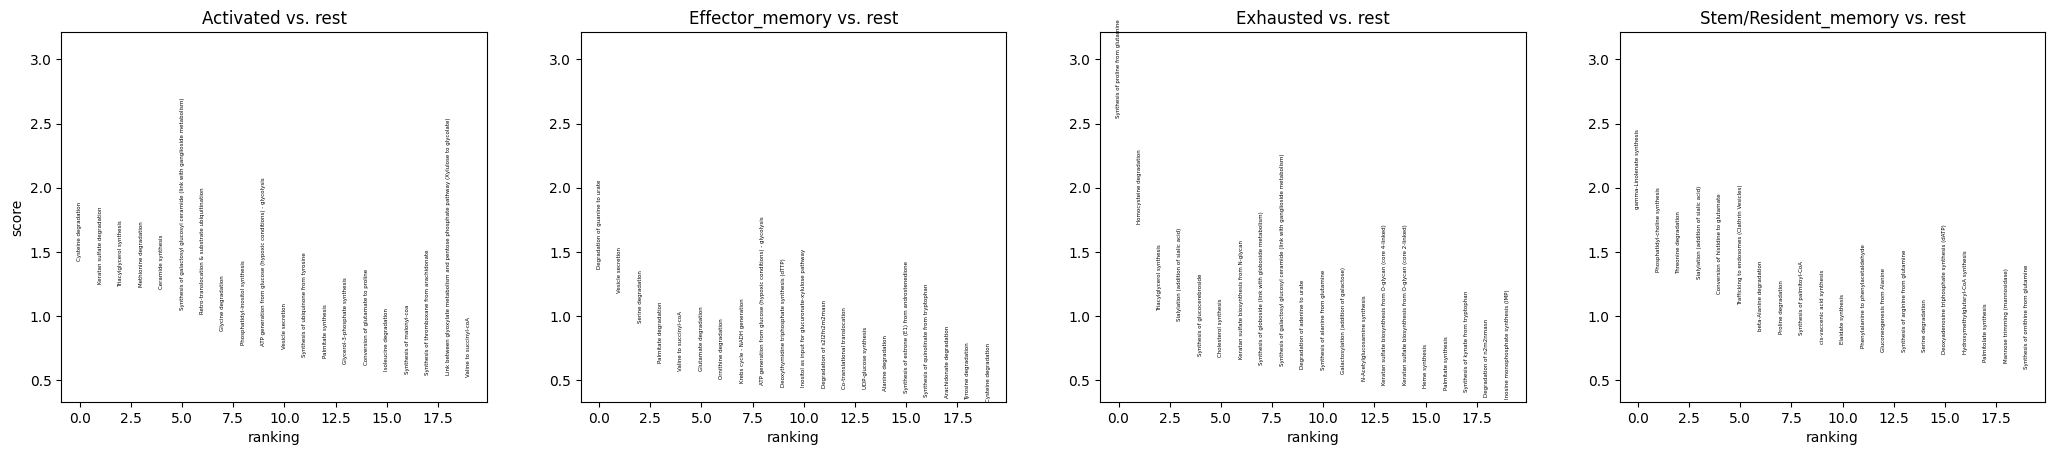

In [15]:
method = 'logreg'
sc.tl.rank_genes_groups(adata.metabolic_tasks, cell_group, method=method,
                       use_raw=False, key_added=method)
sc.pl.rank_genes_groups(adata.metabolic_tasks, n_genes=20, sharey=True, key=method, fontsize=4)

In [16]:
# Get the results as a dataframe
scanpy_df = sc.get.rank_genes_groups_df(adata.metabolic_tasks,
                                      key=method,
                                      group=None)

In [17]:
scanpy_df

,group,names,scores
0,Activated,Cysteine degradation,1.429167
1,Activated,Keratan sulfate degradation,1.248796
2,Activated,Triacylglycerol synthesis,1.228897
3,Activated,Methionine degradation,1.226988
4,Activated,Ceramide synthesis,1.213782
...,...,...,...
731,Stem/Resident_memory,Cysteine degradation,-1.194718
732,Stem/Resident_memory,Synthesis of galactosyl glucosyl ceramide (lin...,-1.218032
733,Stem/Resident_memory,Synthesis of proline from glutamine,-1.349030
734,Stem/Resident_memory,Methionine degradation,-1.593266


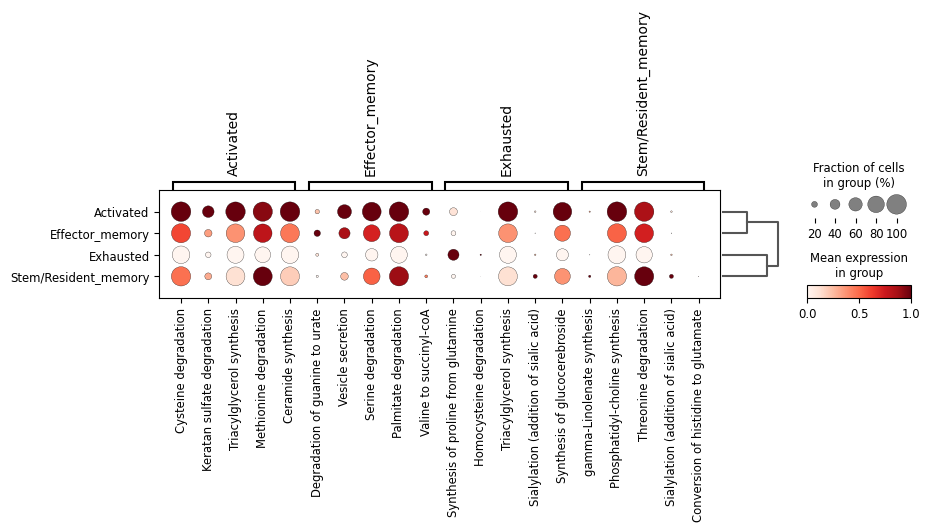

In [18]:
sc.pl.rank_genes_groups_dotplot(adata.metabolic_tasks, n_genes=5, groupby=cell_group,
                               key=method, use_raw=False, standard_scale='var',
                              )

<Axes: >

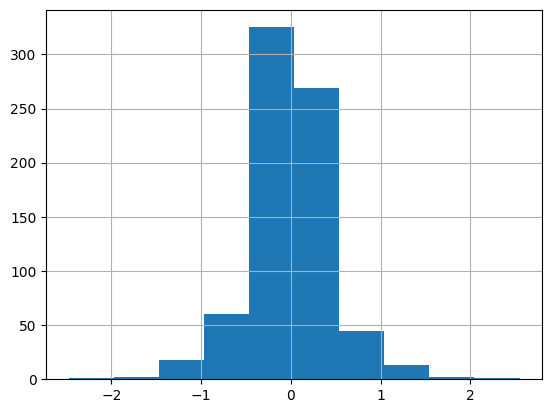

In [19]:
scanpy_df['scores'].hist()

In [20]:
# Filter based on score threshold
scores_threshold = 0.5
filtered_scanpy_mrks = scanpy_df.loc[scanpy_df['scores'] > scores_threshold]

In [21]:
filtered_scanpy_mrks

,group,names,scores
0,Activated,Cysteine degradation,1.429167
1,Activated,Keratan sulfate degradation,1.248796
2,Activated,Triacylglycerol synthesis,1.228897
3,Activated,Methionine degradation,1.226988
4,Activated,Ceramide synthesis,1.213782
...,...,...,...
573,Stem/Resident_memory,Conversion of GABA into succinate,0.564559
574,Stem/Resident_memory,Sphingomyelin synthesis,0.552321
575,Stem/Resident_memory,Synthesis of coenzyme A,0.550766
576,Stem/Resident_memory,Krebs cycle - NADH generation,0.514109


In [22]:
# Convert them to a list
scanpy_mrks = filtered_scanpy_mrks['names'].unique().tolist()
len(scanpy_mrks)

64

## Visualization

In [23]:
both_markers = sorted(set(tf_idf_mrks + scanpy_mrks))
len(both_markers)

71

In [24]:
# Aggregate the metabolic activity of markers into a cell-type level using trimean
agg = sccellfie.expression.aggregation.agg_expression_cells(adata.metabolic_tasks[:, both_markers],
                                                            groupby=cell_group,
                                                            agg_func='trimean')

In [25]:
agg

Task,ATP generation from glucose (hypoxic conditions) - glycolysis,Ceramide synthesis,Cholesterol synthesis,Conversion of GABA into succinate,Conversion of glutamate to proline,Conversion of glycine to pyruvate,Conversion of histidine to glutamate,Cysteine degradation,Degradation of adenine to urate,Degradation of guanine to urate,...,Threonine degradation,Trafficking to endosomes (Clathrin Vesicles),Triacylglycerol synthesis,UDP-glucuronate synthesis,Valine to succinyl-coA,Vesicle secretion,beta-Alanine degradation,cis-vaccenic acid synthesis,gamma-Linolenate degradation,gamma-Linolenate synthesis
Activated,0.988974,0.349889,0.060343,0.0,0.0,0.0,0.0,0.319205,0.000000,0.0,...,0.353421,0.024781,0.316884,0.227842,0.002461,0.076902,0.386538,0.460776,0.375369,0.0
Effector_memory,0.765522,0.267784,0.029273,0.0,0.0,0.0,0.0,0.258952,0.016977,0.0,...,0.337637,0.016171,0.239191,0.210881,0.000000,0.042015,0.339628,0.392067,0.342867,0.0
Exhausted,0.450257,0.177733,0.040595,0.0,0.0,0.0,0.0,0.158295,0.000000,0.0,...,0.206944,0.000000,0.189210,0.164228,0.000000,0.000000,0.222018,0.275154,0.203770,0.0
Stem/Resident_memory,0.515978,0.214329,0.012547,0.0,0.0,0.0,0.0,0.236784,0.000000,0.0,...,0.384238,0.000000,0.203211,0.042258,0.000000,0.017953,0.344207,0.424837,0.356821,0.0


In [26]:
both_markers = agg.T.loc[(agg.T > 0.5).any(axis=1)].index.tolist()
len(both_markers)

7

In [27]:
both_markers

['ATP generation from glucose (hypoxic conditions) - glycolysis',
 'Hydroxymethylglutaryl-CoA synthesis',
 'Link between glyoxylate metabolism and pentose phosphate pathway (Xylulose to glycolate)',
 'Palmitate synthesis',
 'Synthesis of malonyl-coa',
 'Synthesis of palmitoyl-CoA',
 'Tetrahydrofolate synthesis']

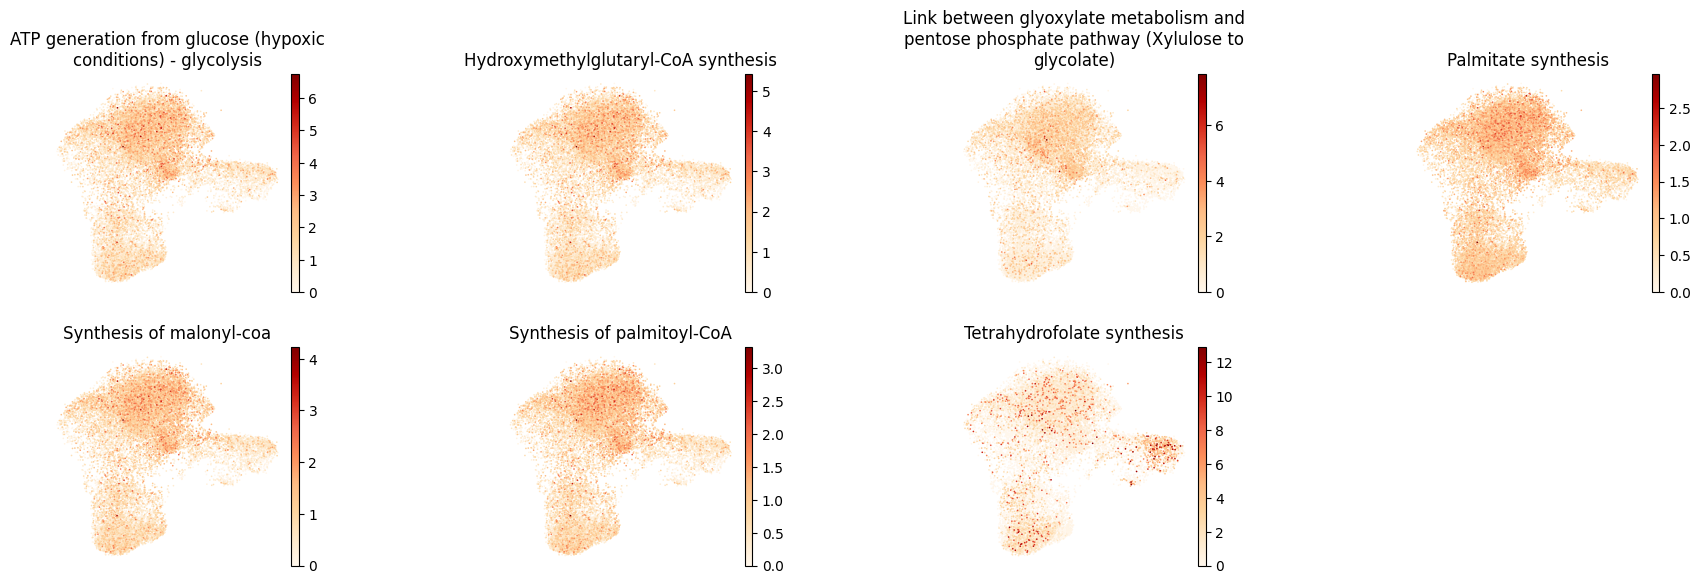

In [28]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams['font.size'] = 10

sc.pl.embedding(adata.metabolic_tasks,
               color=both_markers,
               ncols=4,
               #palette=palette,
               frameon=False,
               basis='X_umap',
               wspace=0.7,
               title=["\n".join(textwrap.wrap(t, width=45)) for t in both_markers],
               cmap='OrRd'
              )

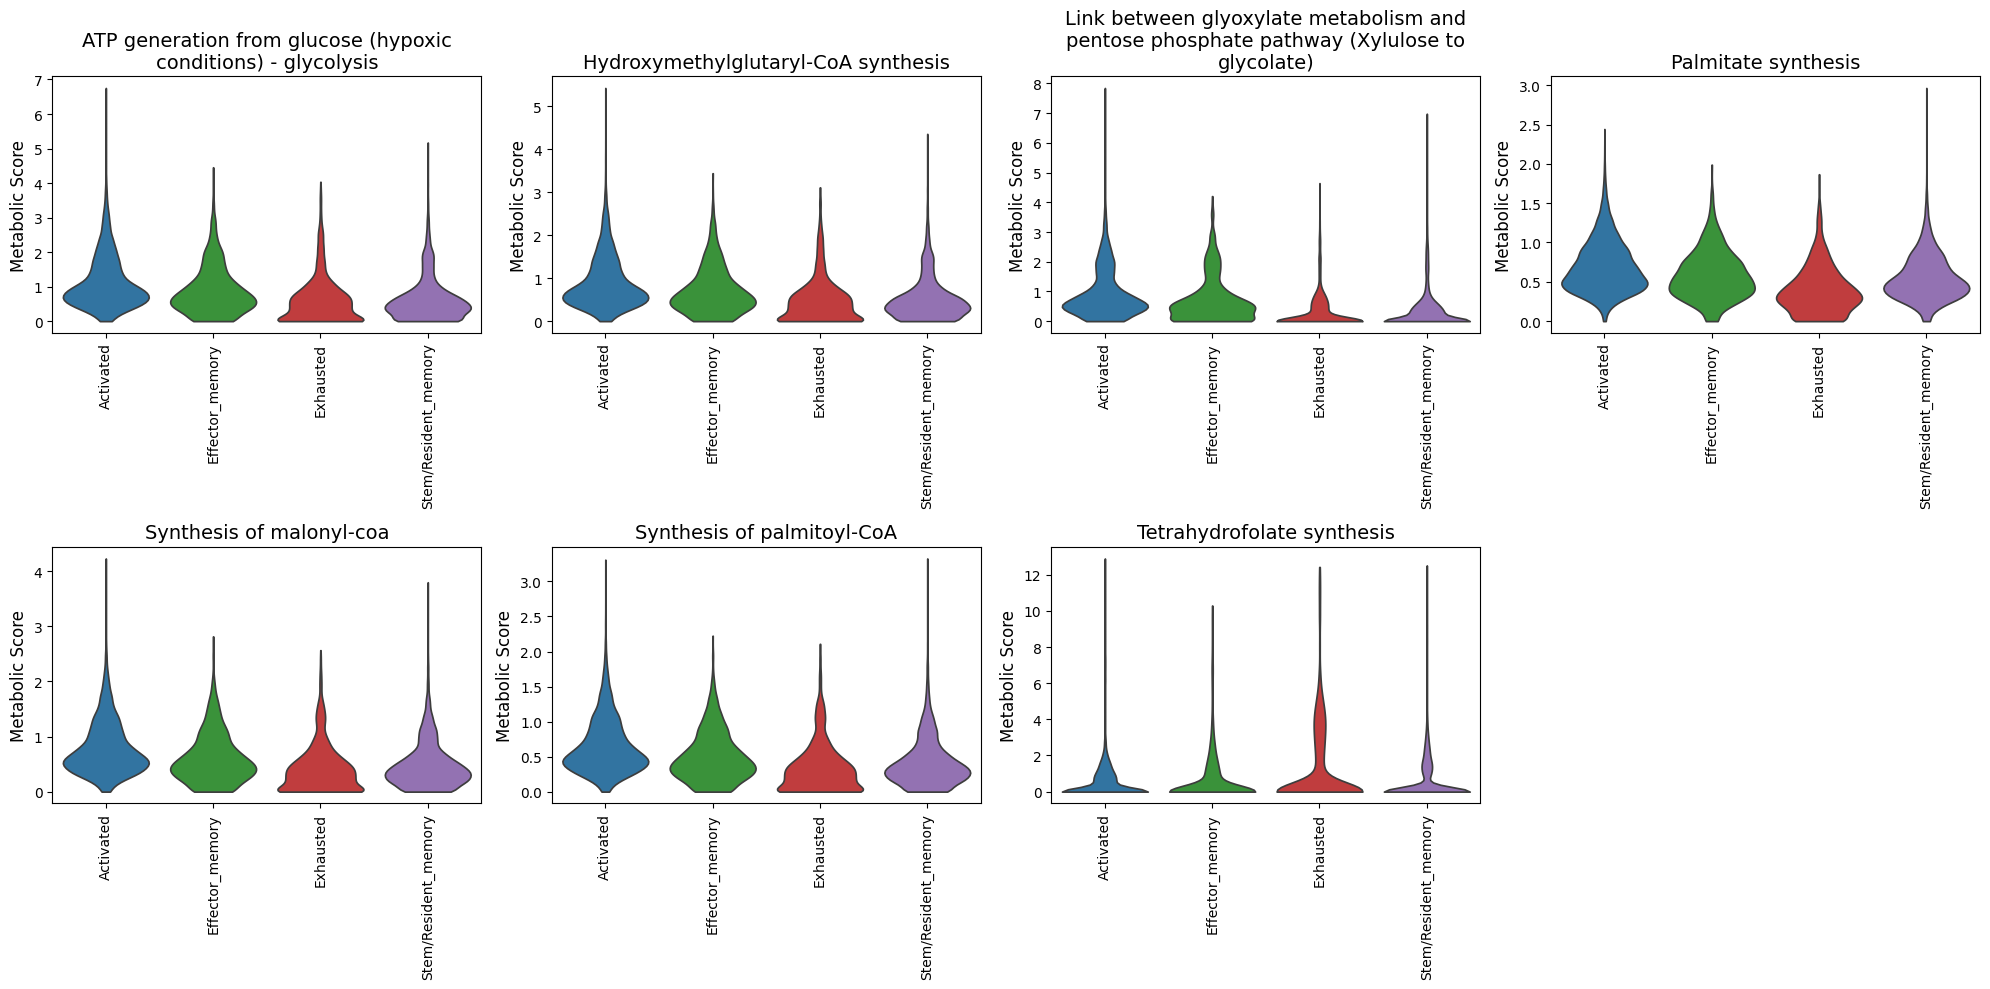

In [29]:
fig, axes = sccellfie.plotting.create_multi_violin_plots(adata.metabolic_tasks,
                                                       features=both_markers,
                                                       groupby=cell_group,
                                                       stripplot=False,
                                                       n_cols=4,
                                                       ylabel='Metabolic Score'
                                                      )

In [30]:
filtered_agg = agg[both_markers]

In [31]:
filtered_agg.head()

Task,ATP generation from glucose (hypoxic conditions) - glycolysis,Hydroxymethylglutaryl-CoA synthesis,Link between glyoxylate metabolism and pentose phosphate pathway (Xylulose to glycolate),Palmitate synthesis,Synthesis of malonyl-coa,Synthesis of palmitoyl-CoA,Tetrahydrofolate synthesis
Activated,0.988974,0.785096,0.751724,0.652972,0.711670,0.584793,0.223576
Effector_memory,0.765522,0.615068,0.535515,0.556072,0.537727,0.444314,0.214925
Exhausted,0.450257,0.368418,0.123774,0.360041,0.334560,0.273886,0.558830
Stem/Resident_memory,0.515978,0.425572,0.203763,0.516287,0.409178,0.354640,0.240220


In [32]:
normalized_markers = sccellfie.preprocessing.min_max_normalization(filtered_agg, axis=0)

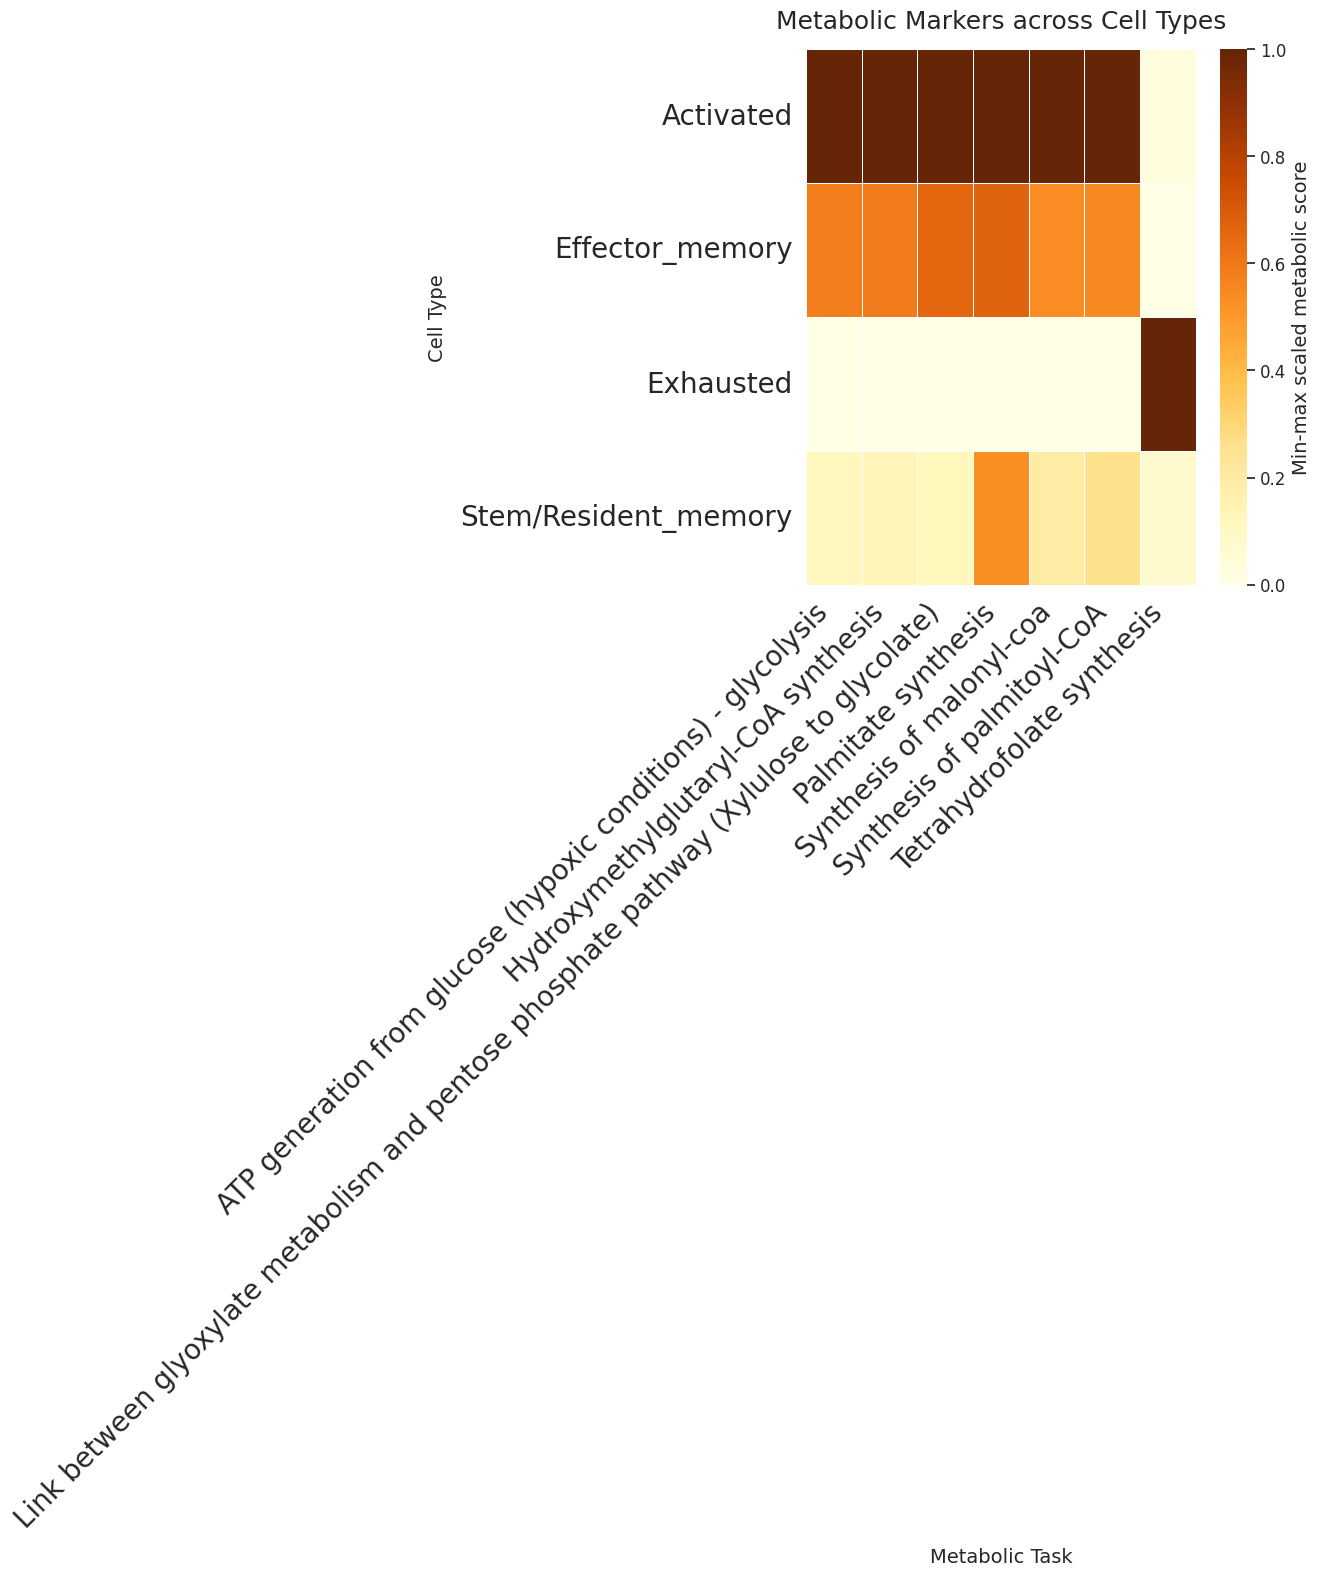

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Option 1: Adjust global font scale for Seaborn (scales everything at once)
sns.set_theme(font_scale=1.2)  # Try 1.2, 1.5, or 2.0 to scale up overall text

# Create figure
plt.figure(figsize=(12, 16))  # Slightly increased figure size for larger labels

# Create heatmap
ax = sns.heatmap(
    normalized_markers,
    cmap="YlOrBr",
    annot=False,
    linewidths=0.5,
    cbar_kws={
        "label": "Min-max scaled metabolic score",
    },
)

# Option 2: Fine-tune individual font sizes
plt.title(
    "Metabolic Markers across Cell Types", fontsize=18, pad=15
)  # Heatmap title
plt.ylabel("Cell Type", fontsize=14, labelpad=10)  # Y-axis label
plt.xlabel("Metabolic Task", fontsize=14, labelpad=10)  # X-axis label

# Increase tick label font sizes (cell type and task names)
plt.xticks(fontsize=20, rotation=45, ha="right")
plt.yticks(fontsize=20, rotation=0)

# Increase colorbar label and tick font size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(14)  # Colorbar title/label size
cbar.ax.tick_params(labelsize=12)  # Colorbar numbers size

plt.tight_layout()
#plt.savefig("metabolic_markers_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()